In [1]:
import keras.src.applications.regnet
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

2023-12-17 11:19:36.775796: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-17 11:19:36.775825: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-17 11:19:36.818253: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-12-17 11:19:36.935279: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-17 11:19:38.215480: W tensorflow/compiler/tf2

In [3]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices:
    tf.config.experimental.set_memory_growth(device, False)
gpu_devices

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [55]:
num_points = 21
values_per_point = 3

model = Sequential()

model.add(Dense(1024, activation='relu', input_shape=(num_points * values_per_point,), kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(24, activation='softmax'))

In [56]:
data_pawel_original = pd.read_csv("datasets/pawel_video_dataset.csv")
data_pawel_moved_01_1 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_01_1.csv")
data_pawel_moved_01_2 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_01_2.csv")
data_pawel_moved_01_3 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_01_3.csv")
data_pawel_moved_01_4 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_01_4.csv")
data_pawel_moved_02_1 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_02_1.csv")
data_pawel_moved_02_2 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_02_2.csv")
data_pawel_moved_02_3 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_02_3.csv")
data_pawel_moved_02_4 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_02_4.csv")
data_pawel_moved_112_1 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_112_1.csv")
data_pawel_moved_112_2 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_112_2.csv")
data_pawel_moved_122_1 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_122_1.csv")
data_pawel_moved_122_2 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_122_2.csv")
data_pawel_moved_211_1 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_211_1.csv")
data_pawel_moved_211_2 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_211_2.csv")
data_pawel_moved_221_1 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_221_1.csv")
data_pawel_moved_221_2 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_221_2.csv")


data_pawel = pd.concat([data_pawel_original, data_pawel_moved_01_1, data_pawel_moved_01_2, data_pawel_moved_01_3, data_pawel_moved_01_4, data_pawel_moved_02_1,
                        data_pawel_moved_02_2, data_pawel_moved_02_3, data_pawel_moved_02_4], ignore_index=True)
data_anita = pd.read_csv("datasets/anita_video_dataset.csv")

In [57]:
X_pawel = data_pawel.iloc[:, :63]
y_pawel = data_pawel.iloc[:, 63:]


X_train, X_val, y_train, y_val = train_test_split(X_pawel, y_pawel, test_size=0.2, random_state=42)

X_train = X_train.values
X_val = X_val.values
y_train = y_train.values
y_val = y_val.values
X_test = data_anita.iloc[:, :63].values
y_test = data_anita.iloc[:, 63:].values

In [5]:
@keras.saving.register_keras_serializable()
def focal_loss(gamma=2., alpha=4.):
    gamma = float(gamma)
    alpha = float(alpha)
    
    def focal_loss_fixed(y_true, y_pred):
        """Focal loss for multi-classification
        FL(p_t)=-alpha * (1-p_t)^gamma * log(p_t)
        where p = softmax score, t = true class
        """
        epsilon = 1.e-9
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        y_true = tf.cast(y_true, tf.float32)
        
        model_out = tf.add(y_pred, epsilon)
        ce = tf.multiply(y_true, -tf.math.log(model_out))
        weight = tf.multiply(y_true, tf.pow(tf.subtract(1., model_out), gamma))
        fl = tf.multiply(alpha, tf.multiply(weight, ce))
        reduced_fl = tf.reduce_max(fl, axis=1)
        return tf.reduce_mean(reduced_fl)
    return focal_loss_fixed

In [65]:
model.compile(loss=focal_loss(), optimizer='adam', metrics=[tf.keras.metrics.Accuracy()])

In [66]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=150, batch_size=1024)

Epoch 1/150
136/136 [==============================] - 4s 9ms/step - loss: 5.2585 - accuracy: 0.0000e+00 - val_loss: 0.4735 - val_accuracy: 0.0000e+00
Epoch 2/150
136/136 [==============================] - 1s 6ms/step - loss: 0.9726 - accuracy: 1.4149e-05 - val_loss: 0.3529 - val_accuracy: 0.0000e+00
Epoch 3/150
136/136 [==============================] - 1s 6ms/step - loss: 0.5981 - accuracy: 7.3452e-05 - val_loss: 0.2743 - val_accuracy: 0.0000e+00
Epoch 4/150
136/136 [==============================] - 1s 6ms/step - loss: 0.4766 - accuracy: 1.6436e-04 - val_loss: 0.2277 - val_accuracy: 0.0000e+00
Epoch 5/150
136/136 [==============================] - 1s 6ms/step - loss: 0.3899 - accuracy: 2.0892e-04 - val_loss: 0.1760 - val_accuracy: 0.0000e+00
Epoch 6/150
136/136 [==============================] - 1s 6ms/step - loss: 0.3185 - accuracy: 3.7027e-04 - val_loss: 0.1607 - val_accuracy: 0.0000e+00
Epoch 7/150
136/136 [==============================] - 1s 6ms/step - loss: 0.2925 - accuracy: 

In [67]:
loss = model.evaluate(X_test, y_test)

 14/204 [=>............................] - ETA: 0s - loss: 2.3920 - accuracy: 0.0000e+00

204/204 [==============================] - 0s 2ms/step - loss: 5.1470 - accuracy: 0.0788


In [68]:
model.save('models/pawel_anita_love_13.keras')

204/204 [==============================] - 0s 1ms/step


Text(0.5, 1.0, 'Macierz Pomyłek')

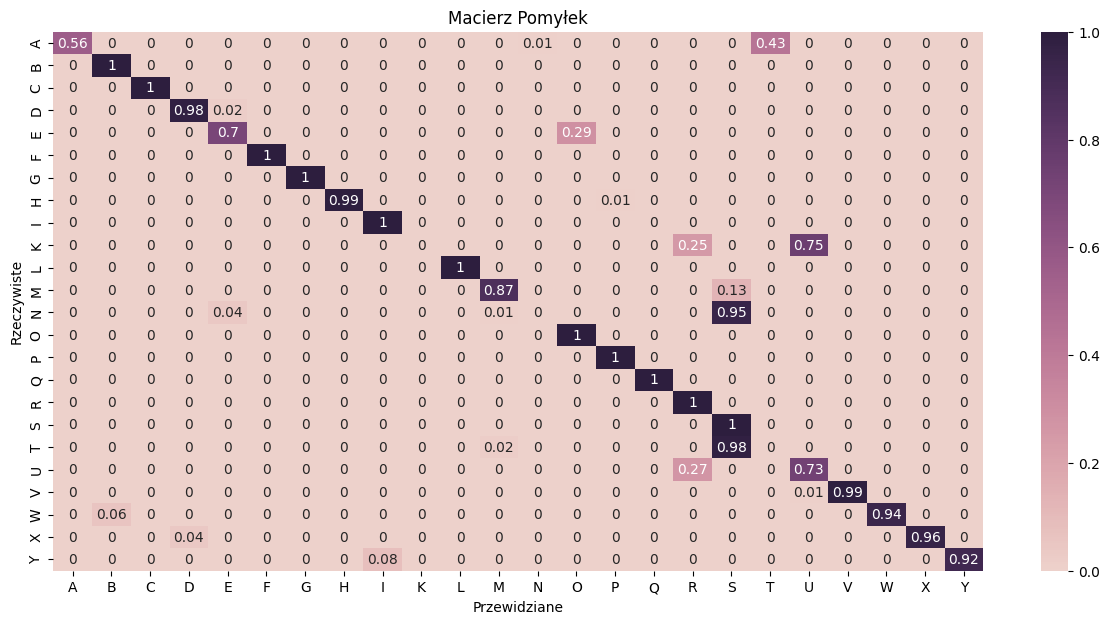

In [69]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm_nn = confusion_matrix(y_true, y_pred_classes)
cm_nn_normalized = cm_nn.astype('float') / 271
cm_nn_normalized_rounded = cm_nn_normalized.round(2)

plt.figure(figsize=(15,7))
klasy = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
sns.heatmap(cm_nn_normalized_rounded, annot=True, fmt='g', cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=klasy, yticklabels=klasy)
plt.plot()
plt.xlabel('Przewidziane')
plt.ylabel('Rzeczywiste')
plt.title('Macierz Pomyłek')